In [1]:
using PlotlyJS
using Infiltrator
using XLSX
include("../model/pre_processing.jl")

# include("../../utils/main.jl")


generate_energy_reserves_cumulative (generic function with 1 method)

In [2]:
function load_deterministic_data(day, input_folder, ε=nothing, ρ=nothing)
    gen_df, loads_multi_df, gen_variable_multi_df, storage_df, random_loads_multi_df = generate_input_data(day, input_folder)
    # required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, reserve)
    file = joinpath(input_folder, G_UC_DATA, "Reserve.csv")
    if isfile(file)
        println("Reserve file found, loading reserves...")                            
        required_reserve = filter_day(day, CSV.read(file, DataFrame))
    else
        println("Reserve file not found, generating reserves...")
        required_reserve = generate_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
    random_loads_multi_df = filter_demand(loads_multi_df, random_loads_multi_df, required_reserve)
    return gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve
end

function load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
    file = joinpath(input_folder, G_UC_DATA, "Energy reserve.csv")
    if isfile(file)
        println("Energy reserve file found, loading reserves...")
        return filter_day(day, CSV.read(file, DataFrame))
    else
        println("Energy reserve file not found, generating reserves...")
        return  generate_energy_reserves(loads_multi_df, gen_variable_multi_df, ε, ρ)
    end
end

load_energy_reserve (generic function with 1 method)

In [3]:
day = 7
input_folder = "../input/base_case_increased_storage_energy_v8.0.8.2"
ε = 0.025
ρ = 0.8
gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
;

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...


Checking that max_{i in T} ER[s,i,t]<=sum(R[S,τ], τ<=t) 

In [4]:
max_required_energy_reserve = combine(groupby(required_energy_reserve, [:t_hour]),[:reserve_up_MW, :reserve_down_MW].=> maximum, renamecols = false)
rename!(max_required_energy_reserve,:t_hour => :hour)
cumsum_required_reserve = combine(required_reserve, [:reserve_up_MW, :reserve_down_MW] .=> cumsum, renamecols = false)
# cumsum_required_reserve.hour .= required_reserve.hour
# cumsum_required_reserve = required_reserve[:, [:hour, :reserve_up_MW, :reserve_down_MW]] .|> cumsum 
delta_reserve = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- max_required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta_reserve.hour .= required_reserve.hour
all.(delta_reserve[:,[:reserve_up_MW, :reserve_down_MW]] .>=0)


Row,reserve_up_MW,reserve_down_MW
,Bool,Bool
1,true,true
2,true,true
3,true,true
4,true,true
5,true,true
6,true,true
7,true,true
8,true,true
9,true,true


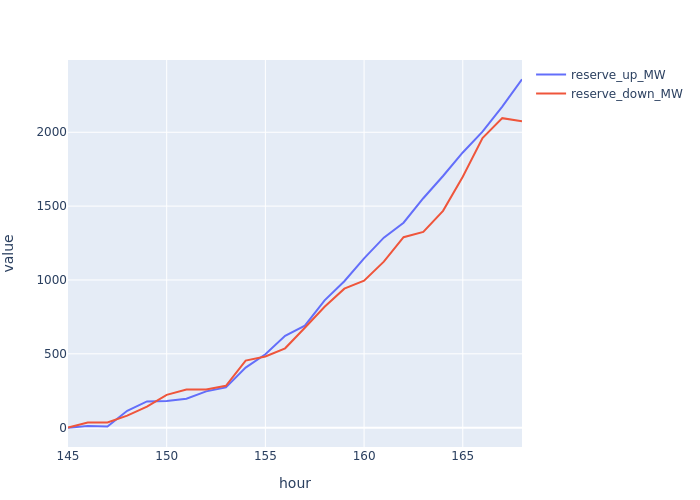

In [5]:
plot(stack(delta_reserve, [:reserve_up_MW, :reserve_down_MW]), x = :hour, y = :value, group = :variable)

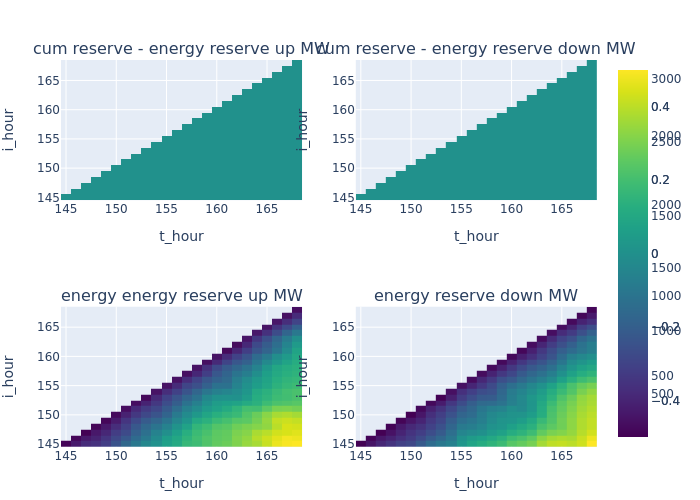

In [6]:
cumsum_required_reserve = required_energy_reserve[:,[:i_hour,:t_hour]] # cumualtive required reserve between i and t
f(i,t,df) = 
    (reserve_up_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_up_MW]),
    reserve_down_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_down_MW]),
    )
transform!(groupby(cumsum_required_reserve,[:i_hour, :t_hour]), [:i_hour, :t_hour] => ((i,t) -> f(i,t,required_reserve)) => AsTable)
;
# delta with energy reserve. 
delta = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta.i_hour .= cumsum_required_reserve.i_hour
delta.t_hour .= cumsum_required_reserve.t_hour
delta[delta.reserve_up_MW .>=0,:reserve_up_MW].= 0
delta[delta.reserve_down_MW .>=0,:reserve_down_MW].= 0
# delta = filter(row -> all(x -> x <= 0, row[[:reserve_up_MW, :reserve_down_MW]]), delta)
;
p1 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_up_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_down_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_up_MW, colorscale="Viridis"), Layout(title="energy energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_down_MW, colorscale="Viridis"), Layout(title="energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
# p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"))
# p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"))
[p1 p2; p3 p4]

In [7]:
include("../model/utils/empirical_mu.jl")
temportal_weights = true
model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve; temportal_weights = temportal_weights)
;


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0x447b37c4
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 2e+01]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 3e+03]
Presolve removed 1912 rows and 2028 columns
Presolve time: 0.03s
Pr

In [8]:
println(value(model[:epsilon_variance]))
println(value(model[:theta]))
println(value(model[:reserve]))
# println(value(model[:slack]))
println(objective_value(model))

3.976103236010576e-5
45213.32295611852
131859.82838035005
-86646.50538447048


In [9]:
# function calculate_mu()
#     mu = []
#     for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
#         aux = collect(skipmissing(sol_1[:, θ] ./ sol_1[:, RES]))
#         push!(mu, mean(values(aux)))
#     end
#     mu_df = DataFrame(mu = mu, variable = ["θUPDIS/RESUPDIS", "θUPCH/RESUPCH", "θDNDIS/RESDNDCH", "θDNCH/RESDNCH"])
#     return unstack(mu_df, :variable, :mu)
# end

function calculate_mu_t(sol_1)
    mu = DataFrame()
    for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
        mu[!, Symbol("$θ/$RES")] = sol_1[:, θ] ./ sol_1[:, RES]
    end
    mu[!, :t] = sol_1.t
    mu = mu[1:end-1, :]
    return unstack(stack(mu, Not(:t)),:t, :value)
end
mu_t = calculate_mu_t(sol_1)



Row,variable,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,θUPDIS/RESUPDIS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.299794,2.00228e-11,8.87448e-12,7.96778e-12,5.64466e-12,3.43875e-12,2.49219e-12,2.54406e-12,2.10258e-12,2.21264e-12,2.25628e-12
2,θUPCH/RESUPCH,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.307416,1.9262e-11,8.73593e-12,7.56176e-12,5.22249e-12,3.21732e-12,2.76728e-12,2.33807e-12,1.96118e-12,1.9368e-12,1.77532e-12
3,θDNDIS/RESDNDIS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.916165,1.77861e-11,9.5736e-12,5.37918e-12,4.02401e-12,3.07385e-12,2.50119e-12,2.42693e-12,2.29171e-12,2.05402e-12
4,θDNCH/RESDNCH,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.923753,2.00766e-11,1.0506e-11,5.27379e-12,4.2523e-12,3.16563e-12,2.75955e-12,2.61809e-12,2.59502e-12,2.58307e-12


┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


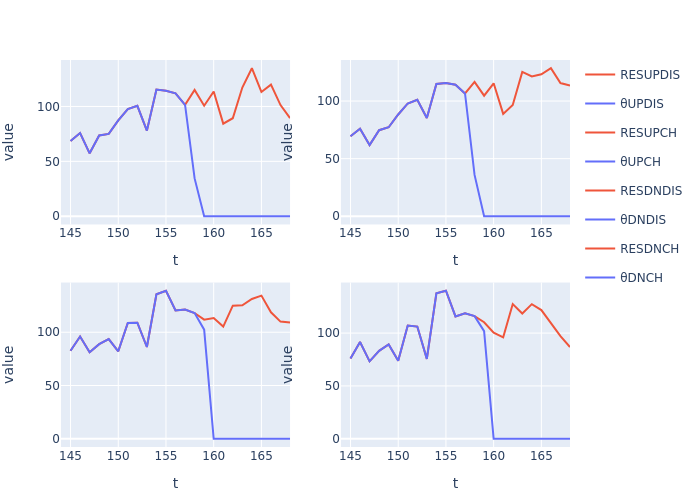

In [10]:
ks = [:θUPDIS,:RESUPDIS]
p1 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θUPCH,:RESUPCH]
p2 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNDIS,:RESDNDIS]
p3 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNCH,:RESDNCH]
p4 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

[p1 p2; p3 p4]

In [11]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sUPDIS, colorscale="Viridis"), Layout(title="sUPDIS", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sUPCH, colorscale="Viridis"), Layout(title="sUPCH", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"), Layout(title="sDNDIS", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"), Layout(title="sDNCH", xaxis_title="t_hour", yaxis_title="i_hour"))
[p1 p2; p3 p4]

ArgumentError: ArgumentError: column name :sUPDIS not found in the data frame

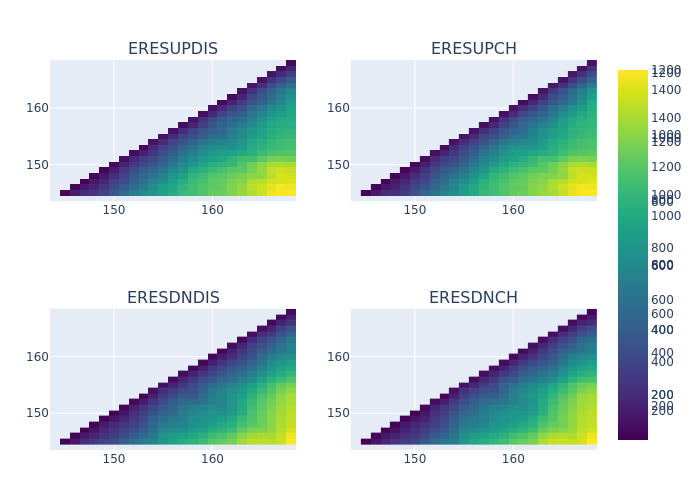

In [82]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPDIS, colorscale="Viridis"), Layout(title="ERESUPDIS"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPCH, colorscale="Viridis"), Layout(title="ERESUPCH"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNDIS, colorscale="Viridis"), Layout(title="ERESDNDIS"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNCH, colorscale="Viridis"), Layout(title="ERESDNCH"))
[p1 p2; p3 p4]

In [86]:
rhos = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.99]
day = 7

ε = 0.025
ρ = 0.8

mu_t_all = DataFrame()
for rho in rhos
    input_folder = "../input/base_case_increased_storage_energy_v8.$(rho).2"
    gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
    required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
    model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve; temportal_weights = temportal_weights)
    mu_t = calculate_mu_t(sol_1)
    mu_t = insertcols(mu_t, 1, :rho => rho)
    append!(mu_t_all, mu_t)
end

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0xe9636ae7
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 2e+01]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range   

In [87]:
transform!(mu_t_all, AsTable(Not([:rho, :variable])) => ByRow(x -> mean(x)) => :mean)

Row,rho,variable,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,mean
,Float64,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64
1,0.0,θUPDIS/RESUPDIS,1.0,0.183492,0.223872,0.258398,0.572241,0.406455,2.27252e-11,0.2107,0.173029,0.61341,0.206675,0.0377165,0.167946,1.44093e-11,2.35538e-11,0.383862,1.10076e-11,2.06215e-11,0.479197,1.14758e-11,1.98798e-11,0.501357,0.276452,0.276352,0.248798
2,0.0,θUPCH/RESUPCH,1.0,0.161084,0.20522,0.255788,0.557949,0.43306,2.25467e-11,0.223416,0.188132,0.510093,0.224741,0.025035,0.190264,1.44766e-11,2.39136e-11,0.415617,1.09186e-11,1.99393e-11,0.430998,1.07336e-11,2.05311e-11,0.519118,0.256419,0.242061,0.243292
3,0.0,θDNDIS/RESDNDIS,1.0,0.443847,0.79347,2.69925e-11,0.000258332,0.269928,0.426454,0.13313,0.530553,0.48039,0.0657068,0.329887,0.26959,0.186444,0.189297,0.893134,0.165816,9.84232e-12,2.37591e-11,0.218068,0.180555,0.434252,2.13855e-11,0.251252,0.302585
4,0.0,θDNCH/RESDNCH,1.0,0.45215,0.811549,3.30375e-11,0.000307623,0.297887,0.486747,0.14574,0.564795,0.463374,0.0663658,0.279122,0.29541,0.231211,0.225796,0.905949,0.181707,8.18146e-12,2.71058e-11,0.258133,0.189508,0.478052,2.35554e-11,0.317436,0.318802
5,0.1,θUPDIS/RESUPDIS,1.0,0.342579,0.135031,0.211247,0.583783,0.399335,0.316666,0.0855844,0.472655,0.222782,0.318345,0.241168,0.710697,1.42365e-11,0.24443,7.01722e-12,1.55098e-11,0.517667,0.155192,4.34727e-12,4.53321e-12,8.0163e-12,1.85417e-11,0.331459,0.262026
6,0.1,θUPCH/RESUPCH,1.0,0.303077,0.124061,0.197385,0.580228,0.40011,0.31963,0.0845292,0.459628,0.211925,0.294875,0.228062,0.693094,1.38278e-11,0.258459,6.95534e-12,1.48558e-11,0.506985,0.134252,3.99074e-12,4.48039e-12,7.53804e-12,1.60558e-11,0.297949,0.253927
7,0.1,θDNDIS/RESDNDIS,1.0,0.218571,0.378958,1.82908e-11,0.389964,0.112287,0.369541,0.247311,0.546833,1.15402e-11,0.48501,0.27906,0.40962,6.62212e-12,1.53814e-11,0.00150455,0.139006,0.541664,5.63044e-12,1.36813e-11,0.0724261,0.130271,0.0462047,0.246795,0.233959
8,0.1,θDNCH/RESDNCH,1.0,0.247541,0.409421,2.09505e-11,0.432795,0.12339,0.401448,0.275754,0.537901,1.19659e-11,0.461752,0.265123,0.447959,6.97762e-12,1.74581e-11,0.00154671,0.148312,0.511419,5.79064e-12,1.4136e-11,0.0795979,0.137566,0.054221,0.287385,0.242631
9,0.2,θUPDIS/RESUPDIS,1.0,0.539791,0.716189,0.240704,0.144595,0.557484,0.0792587,0.179426,0.264813,0.4791,0.383904,0.623416,5.77288e-12,1.18475e-11,0.00973628,0.223045,0.0406356,0.347067,0.924268,0.265318,5.75979e-12,6.88166e-12,1.58837e-11,0.137343,0.298171


In [88]:
using CSV
CSV.write("mu_t_all.csv", mu_t_all) 

"mu_t_all.csv"